In [2]:
# ==============================================================================
# A.1. Импорт библиотек и загрузка обработанного датасета
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Устанавливаем стиль для графиков
sns.set_style("whitegrid")
print("Библиотеки успешно импортированы.")

# --- Загрузка данных ---
# [Важно!] Убедитесь, что путь к файлу указан верно.
# Скрипт сохранял его в 'data/processed/'. Ноутбук находится в 'notebooks/'.
# Значит, относительный путь будет '../data/processed/featured_dataset.csv'
featured_data_path = '../data/processed/featured_dataset.csv'

try:
    df_featured = pd.read_csv(featured_data_path)
    print(f"Обработанный датасет успешно загружен. Путь: '{featured_data_path}'")

except FileNotFoundError:
    print(f"Ошибка: Файл не найден по пути '{featured_data_path}'.")
    print("Пожалуйста, убедитесь, что вы запустили скрипт предобработки, и проверьте путь.")
    df_featured = None

Библиотеки успешно импортированы.
Обработанный датасет успешно загружен. Путь: '../data/processed/featured_dataset.csv'


In [3]:
# ==============================================================================
# A.2. Общая информация и проверка структуры
# ==============================================================================
if df_featured is not None:
    print("--- Общая информация о датасете ---")
    print(f"Форма датасета (строки, колонки): {df_featured.shape}")
    print("\n--- Типы данных ---")
    print(df_featured.dtypes.value_counts())
    
    print("\n--- Первые 5 строк датасета ---")
    display(df_featured.head())
    
    # Подсчет количества созданных признаков
    original_cols = ['id', 'date', 'E_mu_Z', 'E_mu_X', 'E_nu1_X', 'E_nu2_X', 
                     'E_nu1_Z', 'E_nu2_Z', 'N_mu_X', 'M_mu_XX', 'M_mu_XZ', 
                     'M_mu_X', 'N_mu_Z', 'M_mu_ZZ', 'M_mu_Z', 'N_nu1_X', 
                     'M_nu1_XX', 'M_nu1_XZ', 'M_nu1_X', 'N_nu1_Z', 'M_nu1_ZZ', 
                     'M_nu1_Z', 'N_nu2_X', 'M_nu2_XX', 'M_nu2_XZ', 'M_nu2_X', 
                     'N_nu2_Z', 'M_nu2_ZZ', 'M_nu2_Z', 'bayesImVoltage', 
                     'synErr', 'N_EC_rounds', 'maintenance_flag', 'E_mu_Z_est', 
                     'R', 's', 'p']
    
    num_generated_features = df_featured.shape[1] - len(original_cols)
    print(f"\nБыло сгенерировано примерно {num_generated_features} новых признаков.")

--- Общая информация о датасете ---
Форма датасета (строки, колонки): (328616, 693)

--- Типы данных ---
float64    682
int64       11
Name: count, dtype: int64

--- Первые 5 строк датасета ---


,id,date,E_mu_Z,E_mu_X,E_nu1_X,E_nu2_X,E_nu1_Z,E_nu2_Z,N_mu_X,M_mu_XX,...,opticalPower_max_per_id,opticalPower_min_per_id,opticalPower_norm_by_id_mean,opticalPower_dist_from_id_mean,s_mean_per_id,s_std_per_id,s_max_per_id,s_min_per_id,s_norm_by_id_mean,s_dist_from_id_mean
0,553405,0,0.01949,0.04331,0.08333,1.0,0.03499,0.44706,6317804.0,531.0,...,56104.6,0.0,1.19623,9185.692069,3902.24812,322.098031,4390,2831,0.960985,-152.24812
1,553405,1,0.01989,0.02814,0.00000,0.0,0.04234,0.45679,6322055.0,533.0,...,56104.6,0.0,1.19623,9185.692069,3902.24812,322.098031,4390,2831,1.011724,45.75188
2,553405,2,0.01923,0.03436,0.00000,0.0,0.03534,0.38462,6320564.0,553.0,...,56104.6,0.0,1.19623,9185.692069,3902.24812,322.098031,4390,2831,1.051189,199.75188
3,553405,3,0.01776,0.02970,0.04000,0.0,0.04264,0.38095,6322326.0,505.0,...,56104.6,0.0,1.19623,9185.692069,3902.24812,322.098031,4390,2831,1.067333,262.75188
4,553405,4,0.01750,0.02829,0.04000,0.5,0.05015,0.45238,6319264.0,601.0,...,56104.6,0.0,1.19623,9185.692069,3902.24812,322.098031,4390,2831,1.055289,215.75188



Было сгенерировано примерно 656 новых признаков.


--- Анализ распределений ключевых признаков ---


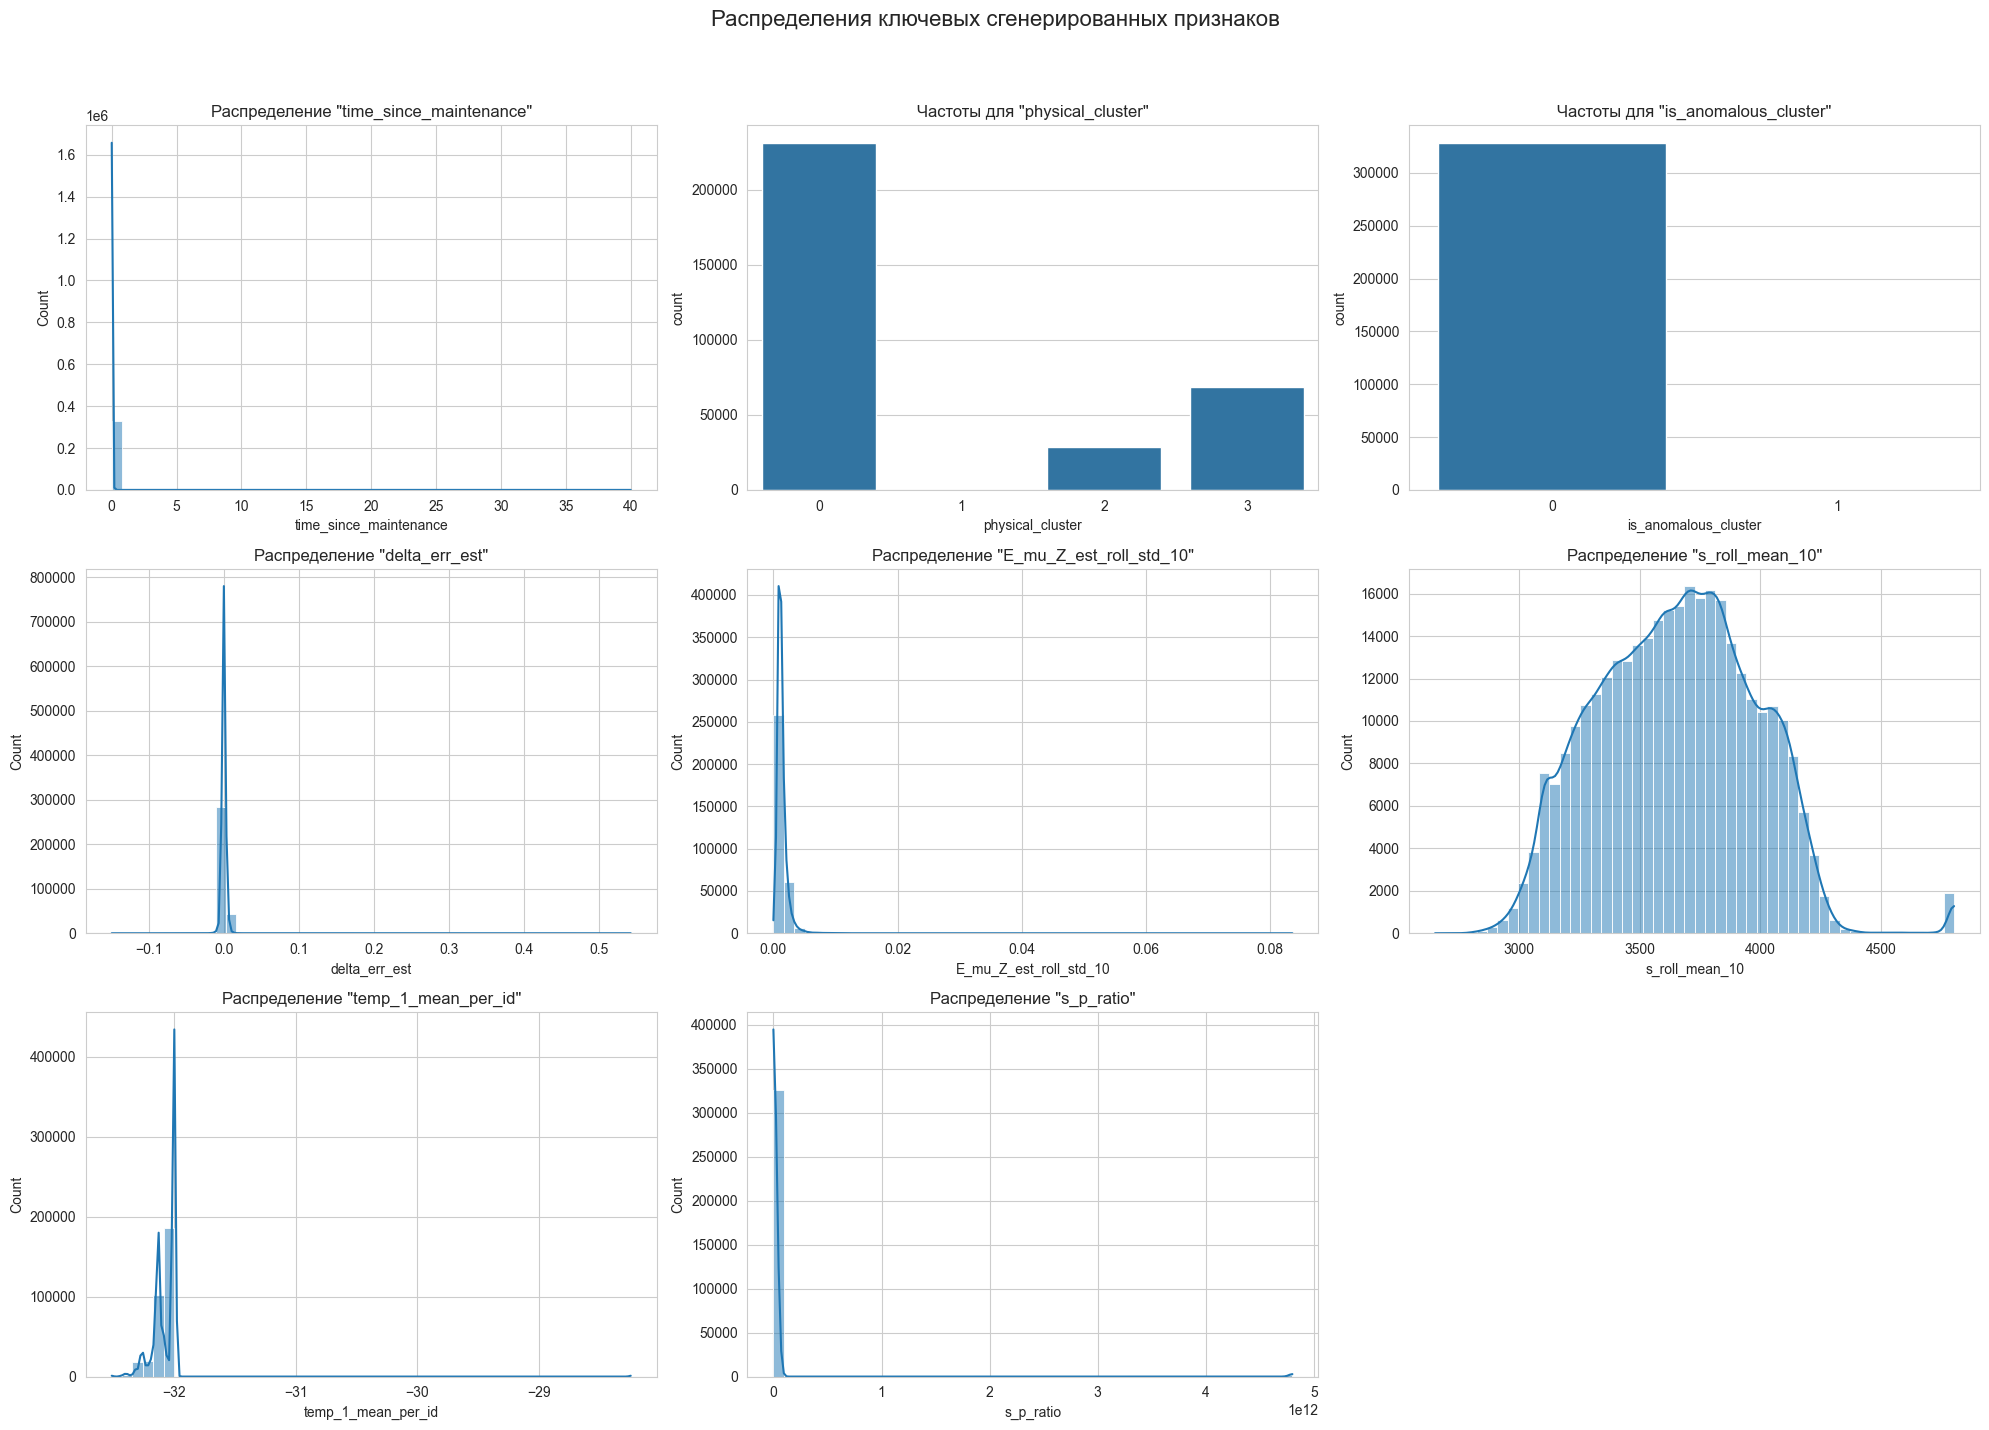


--- Описательные статистики для этих признаков ---


,count,mean,std,min,25%,50%,75%,max
time_since_maintenance,328616.0,3.406712e-02,8.004336e-01,0.000000,0.000000,0.000000,0.000000,4.000000e+01
physical_cluster,328616.0,7.991181e-01,1.258179e+00,0.000000,0.000000,0.000000,2.000000,3.000000e+00
is_anomalous_cluster,328616.0,1.521533e-04,1.233412e-02,0.000000,0.000000,0.000000,0.000000,1.000000e+00
delta_err_est,328616.0,-9.980768e-06,3.327574e-03,-0.149170,-0.001620,-0.000180,0.001510,5.418200e-01
E_mu_Z_est_roll_std_10,327793.0,1.346264e-03,1.126734e-03,0.000000,0.000871,0.001159,0.001568,8.362837e-02
s_roll_mean_10,328616.0,3.650857e+03,3.202232e+02,2655.000000,3407.100000,3658.200000,3882.200000,4.800000e+03
temp_1_mean_per_id,328616.0,-3.206881e+01,1.609160e-01,-32.511548,-32.132370,-32.008224,-32.000000,-2.824584e+01
s_p_ratio,328616.0,3.385836e+10,4.017141e+11,1.081526,1.787456,3.678363,6.754443,4.800000e+12


In [4]:
# ==============================================================================
# A.3. Анализ распределений ключевых сгенерированных признаков
# ==============================================================================
if df_featured is not None:
    key_generated_features = [
        'time_since_maintenance',
        'physical_cluster',
        'is_anomalous_cluster',
        'delta_err_est',
        'E_mu_Z_est_roll_std_10', # Пример волатильности
        's_roll_mean_10',         # Пример сглаживания
        'temp_1_mean_per_id',     # Пример агрегата по сессии
        's_p_ratio'
    ]

    print("--- Анализ распределений ключевых признаков ---")
    
    plt.figure(figsize=(20, 15))
    plt.suptitle("Распределения ключевых сгенерированных признаков", fontsize=16)

    for i, col in enumerate(key_generated_features, 1):
        plt.subplot(3, 3, i)
        if df_featured[col].nunique() > 20: # Гистограмма для непрерывных
            sns.histplot(df_featured[col], kde=True, bins=50)
            plt.title(f'Распределение "{col}"')
        else: # Countplot для категориальных/дискретных
            sns.countplot(x=df_featured[col])
            plt.title(f'Частоты для "{col}"')
            
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    print("\n--- Описательные статистики для этих признаков ---")
    display(df_featured[key_generated_features].describe().T)

--- Топ-20 признаков по корреляции Пирсона с 'E_mu_Z' ---


E_mu_Z                              1.000000
E_mu_Z_est                          0.958998
inter_temp_2_x_E_mu_Z_est           0.952439
inter_biasVoltage_2_x_E_mu_Z_est    0.952439
inter_biasVoltage_1_x_E_mu_Z_est    0.952439
inter_temp_1_x_E_mu_Z_est           0.952302
E_mu_Z_est_roll_min_10              0.952227
E_mu_Z_est_ewm_5                    0.950095
E_mu_Z_est_roll_mean_10             0.950055
E_mu_Z_est_roll_min_5               0.945732
E_mu_Z_est_roll_mean_5              0.942379
E_mu_Z_est_lag_1                    0.941876
E_mu_Z_est_mean_per_id              0.939372
E_mu_Z_est_roll_max_5               0.937714
E_mu_Z_est_roll_max_10              0.936397
E_mu_Z_est_lag_5                    0.931420
E_mu_Z_est_lag_2                    0.930952
E_mu_Z_est_lag_3                    0.926284
E_mu_Z_est_min_per_id               0.915284
R                                   0.854933
inter_opticalPower_x_E_mu_Z_est     0.807189
Name: E_mu_Z, dtype: float64


--- Топ-20 признаков по корреляции Пирсона с 'N_EC_rounds' ---


N_EC_rounds                 1.000000
delta_err_est               0.568017
E_mu_Z_est_diff             0.360978
E_mu_X_norm_by_id_mean      0.202947
E_nu1_Z                     0.161606
s_mean_per_id               0.155081
E_mu_X_dist_from_id_mean    0.120770
E_mu_Z                      0.113441
s_roll_max_10               0.112800
E_mu_Z_est_lag_2            0.101825
E_mu_Z_est_lag_3            0.101500
s                           0.095974
p                           0.095974
s_max_per_id                0.093604
s_roll_mean_10              0.088479
E_nu1_Z_lag_5               0.086863
E_mu_Z_est_roll_mean_5      0.085344
E_mu_Z_est_lag_1            0.084559
E_nu1_Z_diff                0.083220
E_mu_Z_est_roll_max_5       0.078213
E_mu_Z_est_roll_min_5       0.077550
Name: N_EC_rounds, dtype: float64

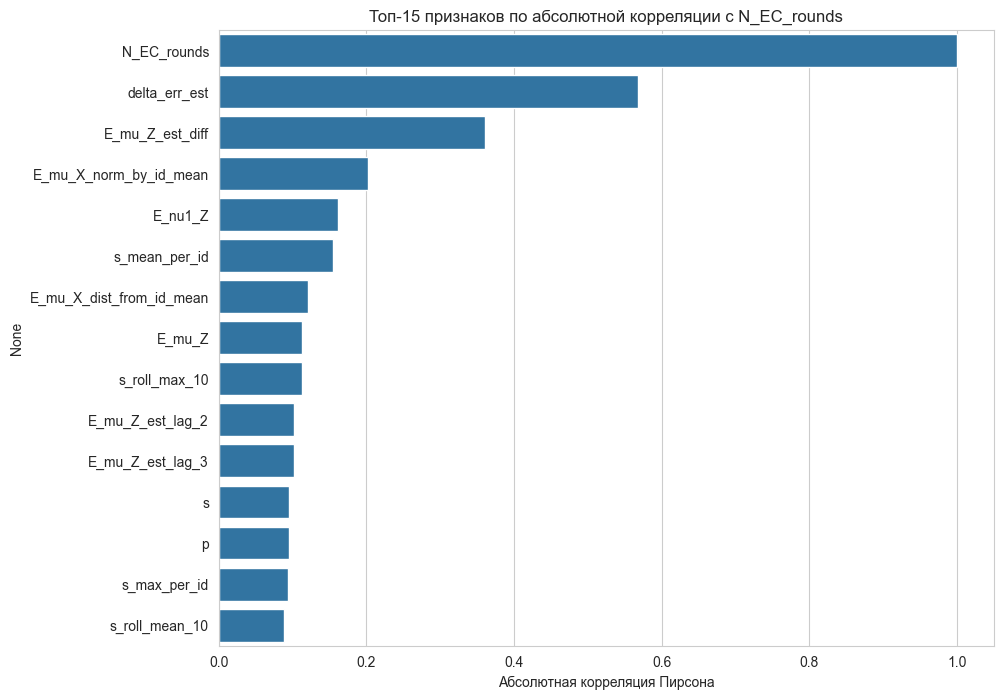

In [5]:
# ==============================================================================
# A.4. Корреляционный анализ с целевыми переменными
# ==============================================================================
if df_featured is not None:
    # Цель для Модели 1: предсказание истинного QBER
    target_1 = 'E_mu_Z'
    # Цель для Модели 2 (Суррогатной): предсказание эффективности
    target_2 = 'N_EC_rounds'
    
    print(f"--- Топ-20 признаков по корреляции Пирсона с '{target_1}' ---")
    corr_target_1 = df_featured.corr(numeric_only=True)[target_1].abs().sort_values(ascending=False)
    display(corr_target_1.head(21)) # 21, чтобы исключить сам таргет

    print(f"\n--- Топ-20 признаков по корреляции Пирсона с '{target_2}' ---")
    corr_target_2 = df_featured.corr(numeric_only=True)[target_2].abs().sort_values(ascending=False)
    display(corr_target_2.head(21)) # 21, чтобы исключить сам таргет

    # Визуализация
    top_features_target_2 = corr_target_2.head(15).index
    
    plt.figure(figsize=(10, 8))
    sns.barplot(x=corr_target_2.head(15).values, y=top_features_target_2)
    plt.title(f'Топ-15 признаков по абсолютной корреляции с {target_2}')
    plt.xlabel('Абсолютная корреляция Пирсона')
    plt.show()

--- Анализ пропусков ---
Общее количество ячеек: 227730888
Общее количество пропусков (NaN): 495446
Процент пропущенных данных: 0.22%

--- Матрица пропусков (для первых 100 признаков) ---


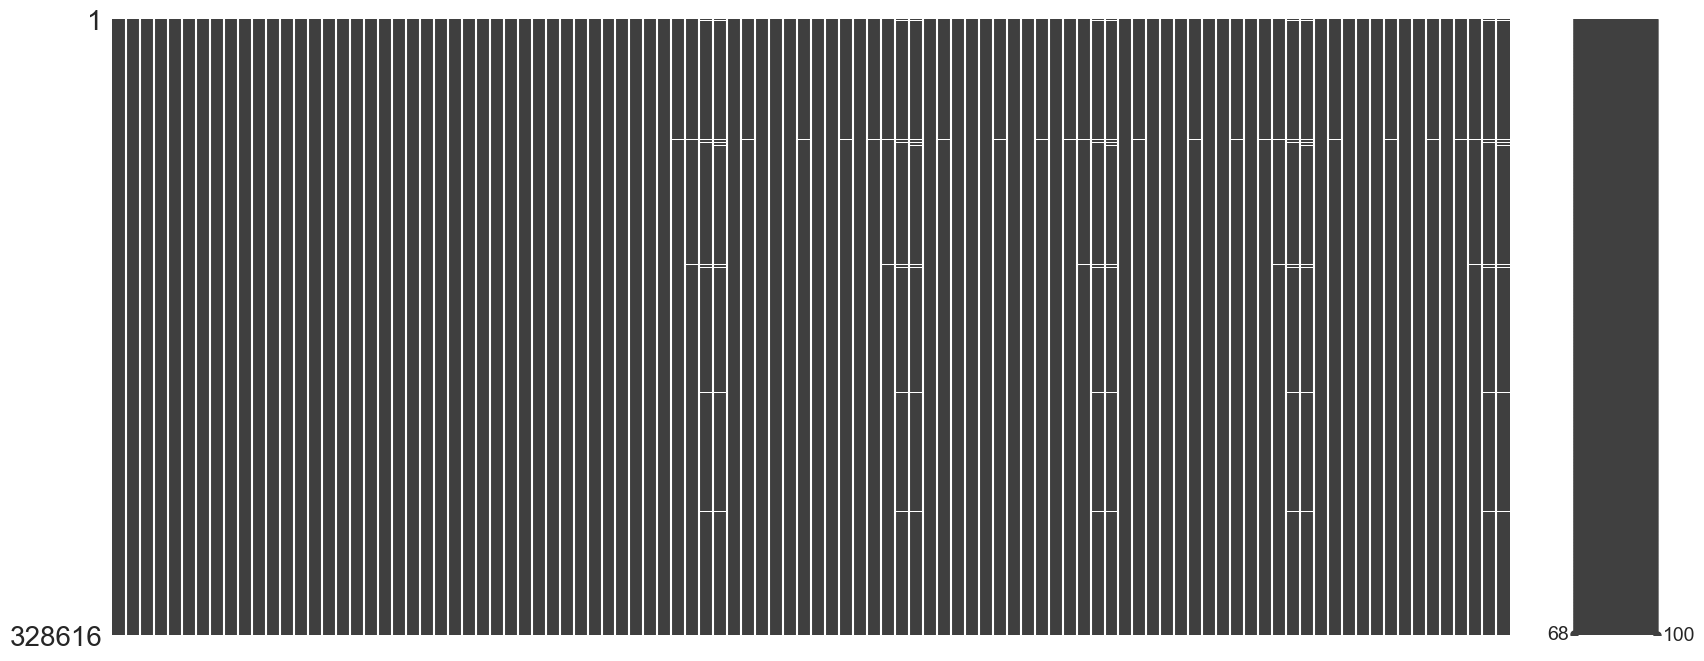


--- Топ-15 признаков по количеству пропусков ---


N_nu2_X_lag_5                   4115
M_nu2_X_lag_5                   4115
E_mu_X_lag_5                    4115
N_nu2_Z_lag_5                   4115
time_since_maintenance_lag_5    4115
M_nu1_ZZ_lag_5                  4115
M_nu1_X_lag_5                   4115
M_nu2_Z_lag_5                   4115
M_nu2_ZZ_lag_5                  4115
N_nu1_Z_lag_5                   4115
polarizerVoltages[2]_lag_5      4115
N_mu_Z_lag_5                    4115
polarizerVoltages[1]_lag_5      4115
M_mu_ZZ_lag_5                   4115
bayesImVoltage_lag_5            4115
dtype: int64

In [7]:
# ==============================================================================
# A.5. Анализ пропусков (NaN)
# ==============================================================================
if df_featured is not None:
    # Исправленный расчет: используем базовое умножение
    total_cells = df_featured.shape[0] * df_featured.shape[1]
    total_missing = df_featured.isnull().sum().sum()
    percent_missing = (total_missing / total_cells) * 100

    print(f"--- Анализ пропусков ---")
    print(f"Общее количество ячеек: {total_cells}")
    print(f"Общее количество пропусков (NaN): {total_missing}")
    print(f"Процент пропущенных данных: {percent_missing:.2f}%")

    # Визуализация матрицы пропусков для первых 100 признаков
    try:
        import missingno as msno
        print("\n--- Матрица пропусков (для первых 100 признаков) ---")
        msno.matrix(df_featured.iloc[:, :100], figsize=(20, 8))
        plt.show()
    except ImportError:
        print("\nБиблиотека 'missingno' не установлена. Пропустите визуализацию матрицы.")
        print("Для установки выполните: pip install missingno")

    print("\n--- Топ-15 признаков по количеству пропусков ---")
    missing_counts = df_featured.isnull().sum().sort_values(ascending=False)
    display(missing_counts.head(15))

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Укажите путь к вашему файлу сабмишена
submission_path = '../submissions/submission_risk_budget_t1_0.0298_t2_0.0771.csv' # Пример пути

try:
    df_sub = pd.read_csv(submission_path, header=None)
    df_sub.columns = ['E_mu_Z_pred', 'R_pred', 's_pred', 'p_pred']
    print(f"Файл '{submission_path}' успешно загружен.")
    
    print("\n--- Описательные статистики для submission-файла ---")
    display(df_sub.describe())
    
except FileNotFoundError:
    print(f"Ошибка: Файл не найден по пути '{submission_path}'.")
    df_sub = None

Файл '../submissions/submission_risk_budget_t1_0.0298_t2_0.0771.csv' успешно загружен.

--- Описательные статистики для submission-файла ---


,E_mu_Z_pred,R_pred,s_pred,p_pred
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.021923,0.746625,3372.221500,1427.778500
std,0.011119,0.032216,328.450651,328.450651
min,0.016432,0.500000,1969.000000,534.000000
25%,0.019194,0.750000,3082.000000,1192.000000
50%,0.020270,0.750000,3384.000000,1416.000000
75%,0.021378,0.750000,3608.000000,1718.000000
max,0.131966,0.800000,4266.000000,2831.000000


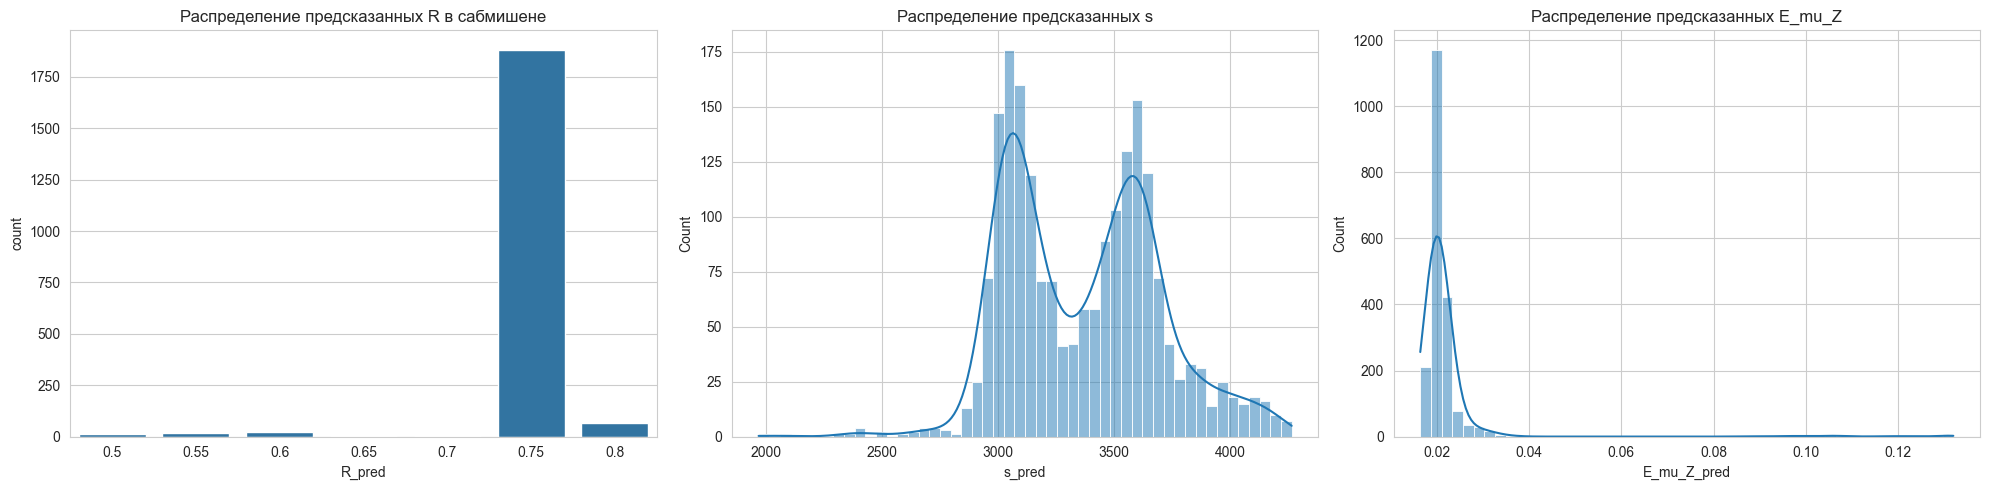

In [11]:
if df_sub is not None:
    plt.figure(figsize=(20, 5))
    
    # Распределение R
    plt.subplot(1, 3, 1)
    sns.countplot(x=df_sub['R_pred'], order=sorted(df_sub['R_pred'].unique()))
    plt.title('Распределение предсказанных R в сабмишене')
    
    # Распределение s
    plt.subplot(1, 3, 2)
    sns.histplot(df_sub['s_pred'], bins=50, kde=True)
    plt.title('Распределение предсказанных s')
    
    # Распределение E_mu_Z
    plt.subplot(1, 3, 3)
    sns.histplot(df_sub['E_mu_Z_pred'], bins=50, kde=True)
    plt.title('Распределение предсказанных E_mu_Z')
    
    plt.tight_layout()
    plt.show()

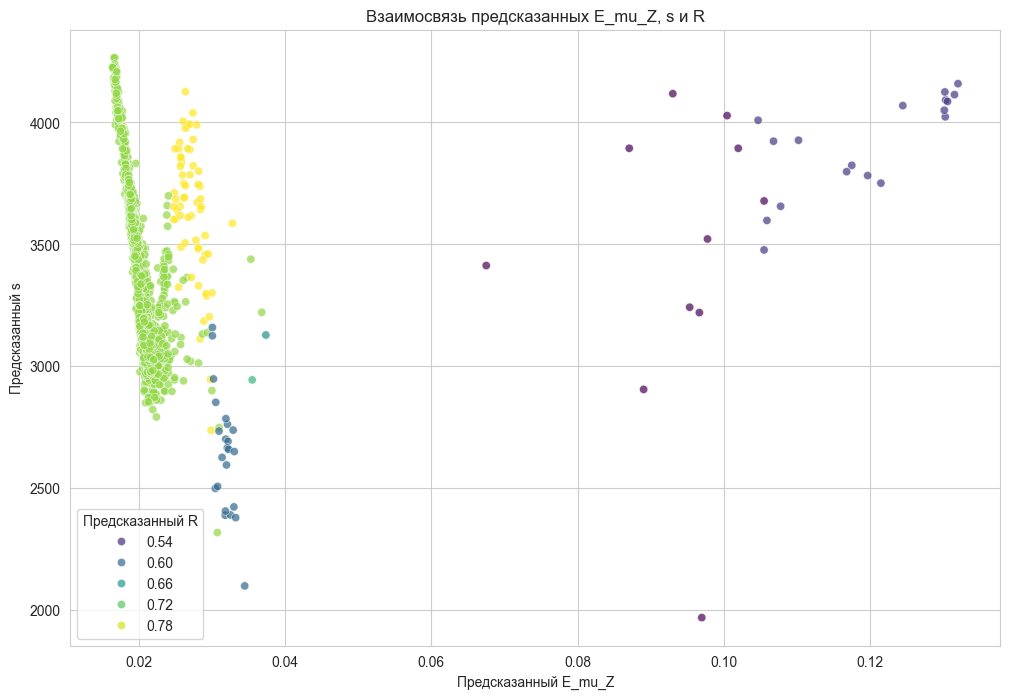

In [12]:
if df_sub is not None:
    plt.figure(figsize=(12, 8))
    sns.scatterplot(data=df_sub, x='E_mu_Z_pred', y='s_pred', hue='R_pred', palette='viridis', alpha=0.7)
    plt.title('Взаимосвязь предсказанных E_mu_Z, s и R')
    plt.xlabel('Предсказанный E_mu_Z')
    plt.ylabel('Предсказанный s')
    plt.legend(title='Предсказанный R')
    plt.show()

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from tqdm.notebook import tqdm 
from pathlib import Path
from sklearn.model_selection import train_test_split

# --- Конфигурация ---
# [Важно!] Убедитесь, что пути верны
PROJECT_ROOT = Path.cwd().parent # Пример, если ноутбук в папке 'notebooks'
INPUT_DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'featured_dataset.csv'
QBER_MODEL_PATH = PROJECT_ROOT / 'models' / 'catboost_QBER_model_optuna.cbm'
SURROGATE_MODEL_PATH = PROJECT_ROOT / 'models' / 'catboost_SURROGATE_model_optuna.cbm'

# Параметры из скрипта обучения, чтобы сделать такое же разделение
SESSION_ID_COL = 'id'
VALIDATION_SIZE = 0.2
RANDOM_STATE = 42

# --- Загрузка моделей ---
print("1. Загрузка обученных моделей...")
try:
    qber_model = CatBoostRegressor().load_model(QBER_MODEL_PATH)
    surrogate_model = CatBoostRegressor().load_model(SURROGATE_MODEL_PATH)
    print("  - Модели успешно загружены.")
except Exception as e:
    print(f"Ошибка при загрузке моделей: {e}")
    qber_model, surrogate_model = None, None

# --- Загрузка и разделение данных для получения val ---
print("\n2. Загрузка и разделение данных для получения валидационной выборки...")
if qber_model and surrogate_model:
    df_featured = pd.read_csv(INPUT_DATA_PATH)
    
    session_ids = df_featured[SESSION_ID_COL].unique()
    train_ids, val_ids = train_test_split(session_ids, test_size=VALIDATION_SIZE, random_state=RANDOM_STATE)
    
    # Нам нужна только валидационная часть
    val_df = df_featured[df_featured[SESSION_ID_COL].isin(val_ids)].copy()
    
    # Возьмем сэмпл для ускорения анализа
    SAMPLE_SIZE = 2000
    if len(val_df) > SAMPLE_SIZE:
        val_sample = val_df.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE)
    else:
        val_sample = val_df
        
    print(f"  - Валидационная выборка получена. Размер сэмпла для анализа: {len(val_sample)} строк.")

1. Загрузка обученных моделей...
  - Модели успешно загружены.

2. Загрузка и разделение данных для получения валидационной выборки...
  - Валидационная выборка получена. Размер сэмпла для анализа: 2000 строк.


In [2]:
def run_vectorized_search(df, qber_model, surrogate_model, alpha):
    """Оптимизированная функция для поиска, возвращает предсказанные R."""
    
    # Шаг 1: Предсказание E_mu_Z
    df['E_mu_Z_pred'] = qber_model.predict(df[qber_model.feature_names_])
    df['E_mu_Z'] = df['E_mu_Z_pred']
    
    # --- Параметры поиска ---
    R_CANDIDATES = np.array([0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9])
    S_CANDIDATES = np.arange(0, 4801, 100)
    TOTAL_CANDIDATES = len(R_CANDIDATES) * len(S_CANDIDATES)
    
    r_grid, s_grid = np.meshgrid(R_CANDIDATES, S_CANDIDATES)
    candidates_df = pd.DataFrame({'R': r_grid.ravel(), 's': s_grid.ravel(), 'p': 4800 - s_grid.ravel()})
    
    # --- Обработка ---
    n_rows = len(df)
    surrogate_features = surrogate_model.feature_names_
    base_feature_names = [f for f in surrogate_features if f not in ['R', 's', 'p']]
    
    base_features = df[base_feature_names]
    repeated_features = pd.DataFrame(np.repeat(base_features.values, TOTAL_CANDIDATES, axis=0), columns=base_feature_names)
    tiled_candidates = pd.concat([candidates_df] * n_rows, ignore_index=True)
    
    search_df = pd.concat([repeated_features, tiled_candidates], axis=1)[surrogate_features]
    
    predicted_log_rounds = surrogate_model.predict(search_df)
    cost = predicted_log_rounds - alpha * search_df['R'].values
    
    cost_matrix = cost.reshape(n_rows, TOTAL_CANDIDATES)
    best_indices = np.argmin(cost_matrix, axis=1)
    
    return candidates_df['R'].iloc[best_indices].values


if 'val_sample' in locals():
    print("\n3. Запуск анализа для разных значений alpha...")
    alpha_results = {}
    
    # Сетка alpha для исследования
    alpha_range = np.linspace(0.1, 2.0, 20) # 20 шагов от 0.1 до 2.0

    for alpha in tqdm(alpha_range, desc="Исследование alpha"):
        predicted_r = run_vectorized_search(val_sample.copy(), qber_model, surrogate_model, alpha)
        alpha_results[alpha] = pd.Series(predicted_r).value_counts(normalize=True).sort_index()

    # Преобразуем результаты в удобный DataFrame
    results_df = pd.DataFrame(alpha_results).T.fillna(0)
    print("  - Анализ завершен.")
    display(results_df.head())


3. Запуск анализа для разных значений alpha...


Исследование alpha:   0%|          | 0/20 [00:00<?, ?it/s]

  - Анализ завершен.


,0.50,0.65,0.70,0.75,0.90
0.1,0.002,0.4910,0.0050,0.0070,0.495
0.2,0.000,0.0960,0.0005,0.0065,0.897
0.3,0.000,0.0095,0.0005,0.0000,0.990
0.4,0.000,0.0050,0.0000,0.0000,0.995
0.5,0.000,0.0020,0.0000,0.0000,0.998



4. Визуализация результатов...


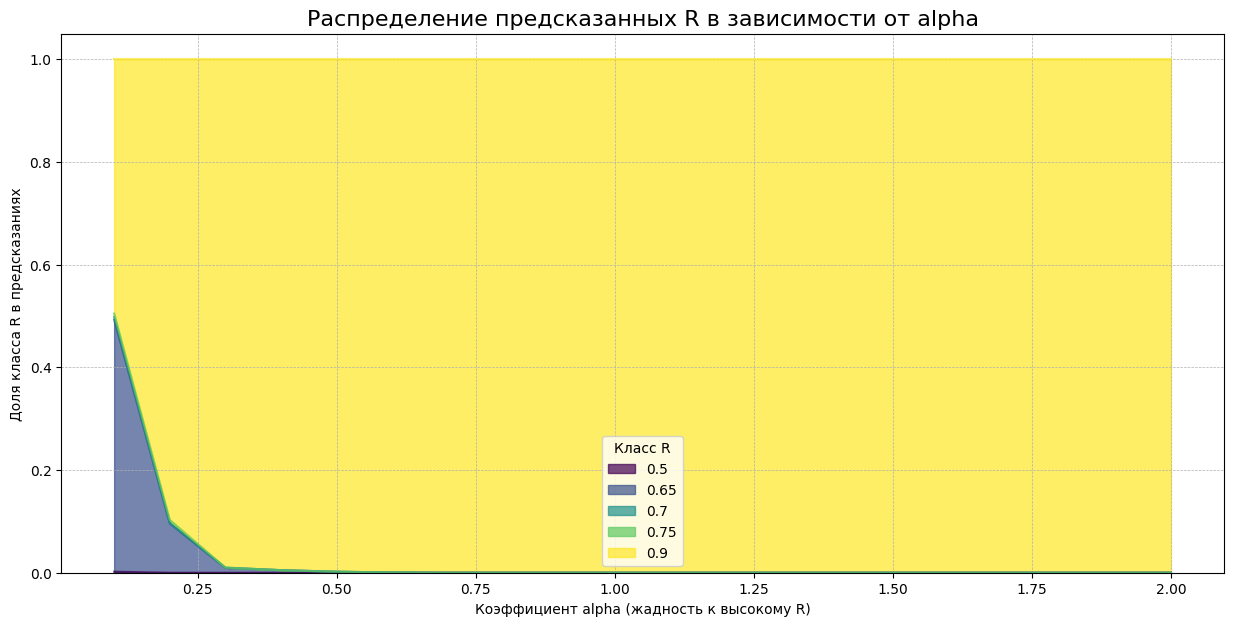

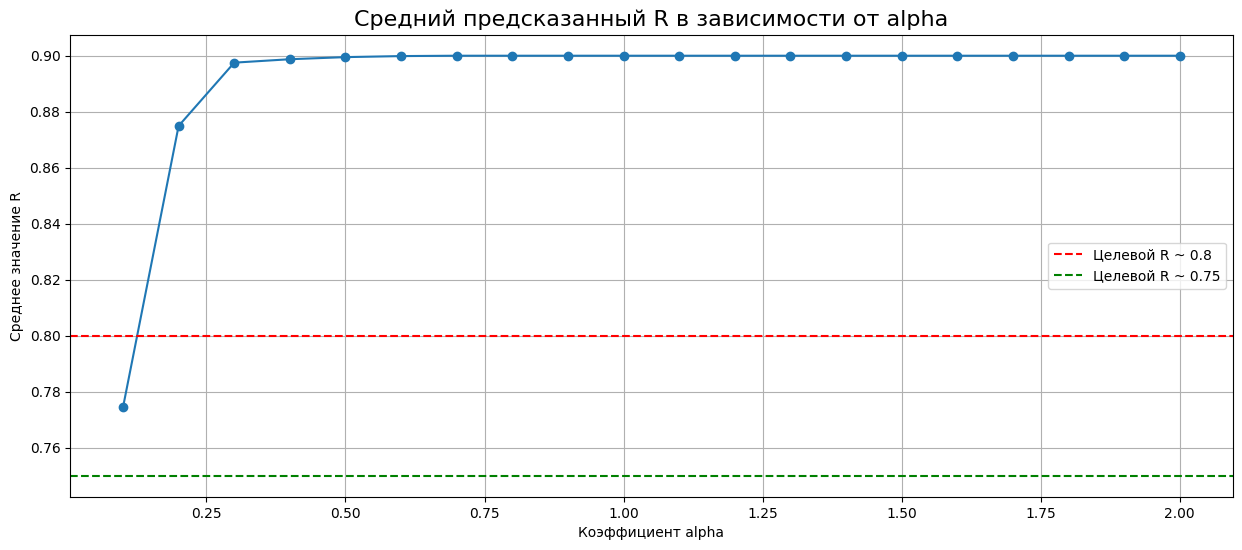


--- Рекомендации ---
Посмотрите на первый график. Идеальный alpha должен давать не один доминирующий цвет, а 'радугу'.
Это значит, что модель гибко подбирает R под разные условия.
На втором графике найдите alpha, который дает средний R в районе 0.75-0.85. Это хорошие кандидаты для сабмита.


In [3]:
if 'results_df' in locals():
    print("\n4. Визуализация результатов...")

    # График 1: Как меняется распределение R от alpha
    results_df.plot(kind='area', stacked=True, figsize=(15, 7),
                    colormap='viridis', alpha=0.7)
    plt.title('Распределение предсказанных R в зависимости от alpha', fontsize=16)
    plt.xlabel('Коэффициент alpha (жадность к высокому R)')
    plt.ylabel('Доля класса R в предсказаниях')
    plt.legend(title='Класс R')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.show()

    # График 2: Как меняется средний R от alpha
    mean_r = (results_df * results_df.columns).sum(axis=1)
    
    plt.figure(figsize=(15, 6))
    mean_r.plot(kind='line', marker='o', grid=True)
    plt.title('Средний предсказанный R в зависимости от alpha', fontsize=16)
    plt.xlabel('Коэффициент alpha')
    plt.ylabel('Среднее значение R')
    
    # Отметим интересные зоны
    plt.axhline(0.8, color='r', linestyle='--', label='Целевой R ~ 0.8')
    plt.axhline(0.75, color='g', linestyle='--', label='Целевой R ~ 0.75')
    plt.legend()
    plt.show()
    
    print("\n--- Рекомендации ---")
    print("Посмотрите на первый график. Идеальный alpha должен давать не один доминирующий цвет, а 'радугу'.")
    print("Это значит, что модель гибко подбирает R под разные условия.")
    print("На втором графике найдите alpha, который дает средний R в районе 0.75-0.85. Это хорошие кандидаты для сабмита.")

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree

sns.set_style("whitegrid")

# Убедитесь, что путь к исходному featured_dataset.csv указан верно
featured_data_path = '../data/processed/featured_dataset.csv'

try:
    df_analysis = pd.read_csv(featured_data_path)
    print(f"Датасет для анализа порогов успешно загружен. Форма: {df_analysis.shape}")
except FileNotFoundError:
    print(f"Ошибка: Файл не найден по пути '{featured_data_path}'.")
    df_analysis = None

Датасет для анализа порогов успешно загружен. Форма: (328616, 693)


In [8]:
if df_analysis is not None:
    print("--- Метод 1: Анализ квантилей E_mu_Z_est для каждого R ---")
    
    # Группируем по R и смотрим на статистики E_mu_Z_est
    qber_stats_by_r = df_analysis.groupby('R')['E_mu_Z_est'].describe(percentiles=[.5, .75, .90, .95])
    
    print("Статистики E_mu_Z_est, сгруппированные по историческому R:")
    display(qber_stats_by_r)
    
    try:
        # Порог t1: граница между "низким" и "средним" риском.
        # Берем 90-й квантиль для R=0.8. Это верхняя граница "безопасного" использования R=0.8.
        t1_candidate = qber_stats_by_r.loc[0.80]['90%']

        # Порог t2: граница между "средним" и "высоким" риском.
        # Берем 90-й квантиль для R=0.7.
        t2_candidate = qber_stats_by_r.loc[0.70]['90%']

        print("\n--- Рекомендуемые пороги (Метод Квантилей) ---")
        print(f"Рекомендуемый t1 (граница низкий/средний риск): ~{t1_candidate:.4f}")
        print(f"Рекомендуемый t2 (граница средний/высокий риск): ~{t2_candidate:.4f}")
        
    except KeyError as e:
        print(f"\nОшибка: не удалось найти R={e} в данных. Возможно, стоит выбрать другой R для анализа.")

--- Метод 1: Анализ квантилей E_mu_Z_est для каждого R ---
Статистики E_mu_Z_est, сгруппированные по историческому R:


,count,mean,std,min,50%,75%,90%,95%,max
R,,,,,,,,,
0.50,4435.0,0.112887,0.014427,0.09040,0.108190,0.125050,0.133682,0.137603,0.23511
0.55,336.0,0.087245,0.001707,0.07783,0.087245,0.088385,0.089675,0.090040,0.09036
0.60,18.0,0.068988,0.004055,0.06364,0.068090,0.071745,0.074772,0.075878,0.07643
0.65,59.0,0.055072,0.003378,0.05050,0.054150,0.058090,0.060226,0.060907,0.06162
0.70,385.0,0.042533,0.002871,0.03923,0.041640,0.044300,0.047118,0.048464,0.05017
0.75,6819.0,0.032508,0.002186,0.02980,0.031940,0.033760,0.035850,0.037062,0.03919
0.80,163065.0,0.022095,0.002028,0.01990,0.021520,0.022910,0.024960,0.026560,0.02979
0.85,153499.0,0.018478,0.000991,0.01387,0.018620,0.019280,0.019650,0.019770,0.01989



--- Рекомендуемые пороги (Метод Квантилей) ---
Рекомендуемый t1 (граница низкий/средний риск): ~0.0250
Рекомендуемый t2 (граница средний/высокий риск): ~0.0471



--- Метод 2: Поиск оптимальных порогов с помощью Дерева Решений ---


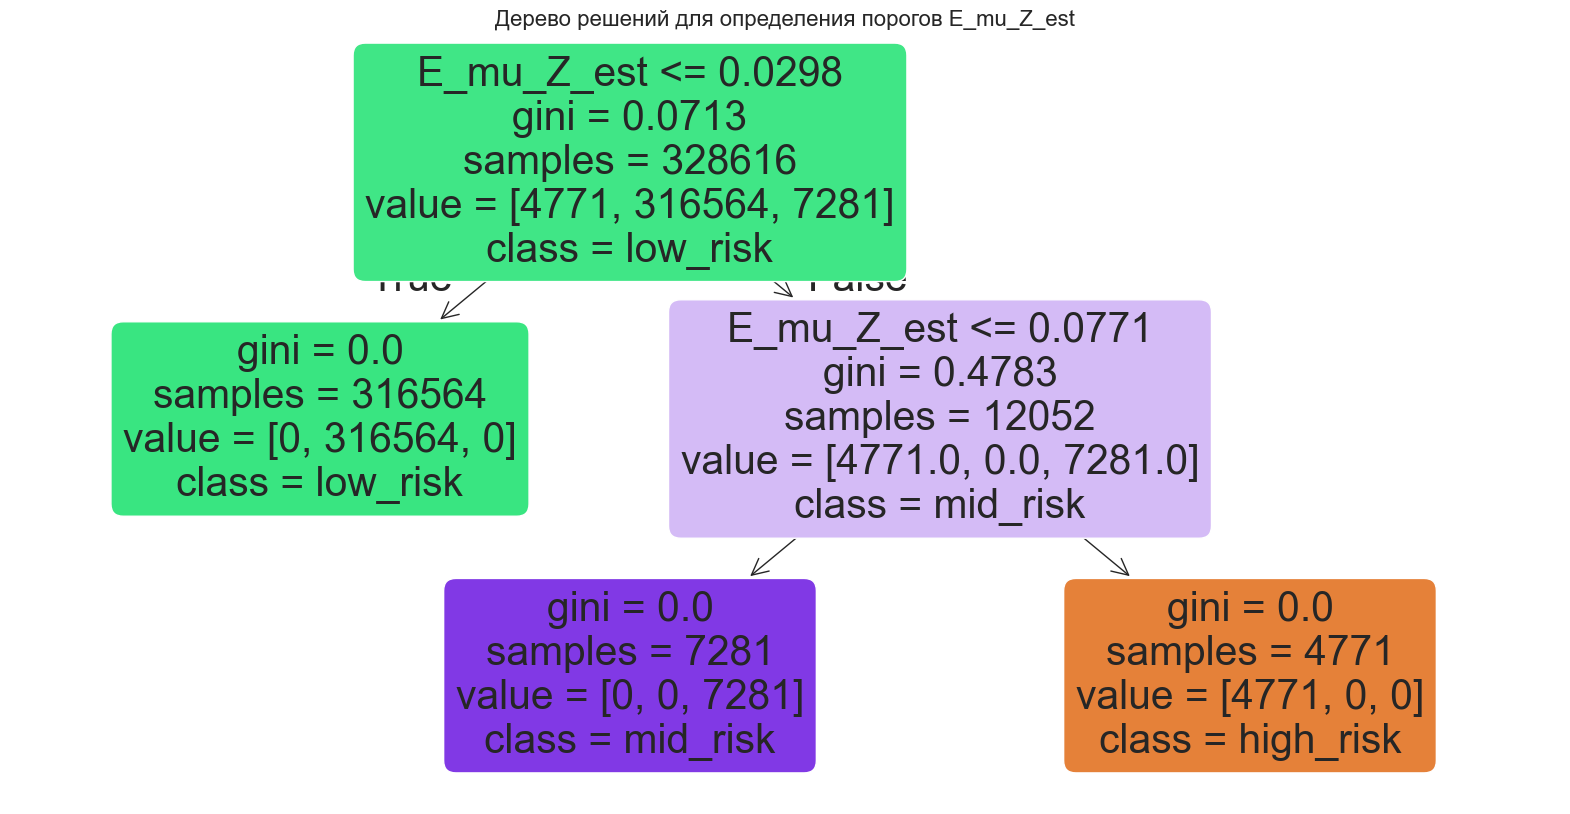


--- Рекомендуемые пороги (Метод Дерева Решений) ---
Рекомендуемый t1 (первый порог): ~0.0298
Рекомендуемый t2 (второй порог): ~0.0771


In [9]:
if df_analysis is not None:
    print("\n--- Метод 2: Поиск оптимальных порогов с помощью Дерева Решений ---")

    # 1. Создаем упрощенную категорию риска
    def get_risk_category(r):
        if r >= 0.8: return 'low_risk'      # R=0.8, 0.85, 0.9
        if r >= 0.6: return 'mid_risk'      # R=0.6, 0.65, 0.7, 0.75
        return 'high_risk'                  # R=0.5, 0.55
        
    df_tree = df_analysis[['E_mu_Z_est', 'R']].copy()
    df_tree['risk_category'] = df_tree['R'].apply(get_risk_category)
    
    # 2. Обучаем простое дерево решений
    # Мы используем только E_mu_Z_est, т.к. именно на него ориентировалась историческая система
    X = df_tree[['E_mu_Z_est']]
    y = df_tree['risk_category']
    
    # max_depth=2, чтобы получить до 3-х порогов (идеально для t1 и t2)
    dt = DecisionTreeClassifier(max_depth=2, random_state=42)
    dt.fit(X, y)
    
    # 3. Визуализируем дерево и извлекаем пороги
    plt.figure(figsize=(20, 10))
    plot_tree(dt, feature_names=['E_mu_Z_est'], class_names=dt.classes_, filled=True, rounded=True, precision=4)
    plt.title("Дерево решений для определения порогов E_mu_Z_est", fontsize=16)
    plt.show()
    
    # Извлекаем пороги из обученного дерева
    thresholds = sorted([node for node in dt.tree_.threshold if node != -2])
    
    print("\n--- Рекомендуемые пороги (Метод Дерева Решений) ---")
    if len(thresholds) >= 2:
        print(f"Рекомендуемый t1 (первый порог): ~{thresholds[0]:.4f}")
        print(f"Рекомендуемый t2 (второй порог): ~{thresholds[1]:.4f}")
    elif len(thresholds) == 1:
        print(f"Дерево нашло только один значимый порог: ~{thresholds[0]:.4f}")
        print("Можно использовать его как t1, а t2 подобрать вручную (например, t1*2).")
    else:
        print("Дереву не удалось найти четких порогов.")